## Comparing Measured vs Predicted RMSE Values
We want to be able to see how well our models are at predicting.

We previously calculated the RMSE of repeated measured values after combining 

Number of binding dedup entries that had dups: 7642


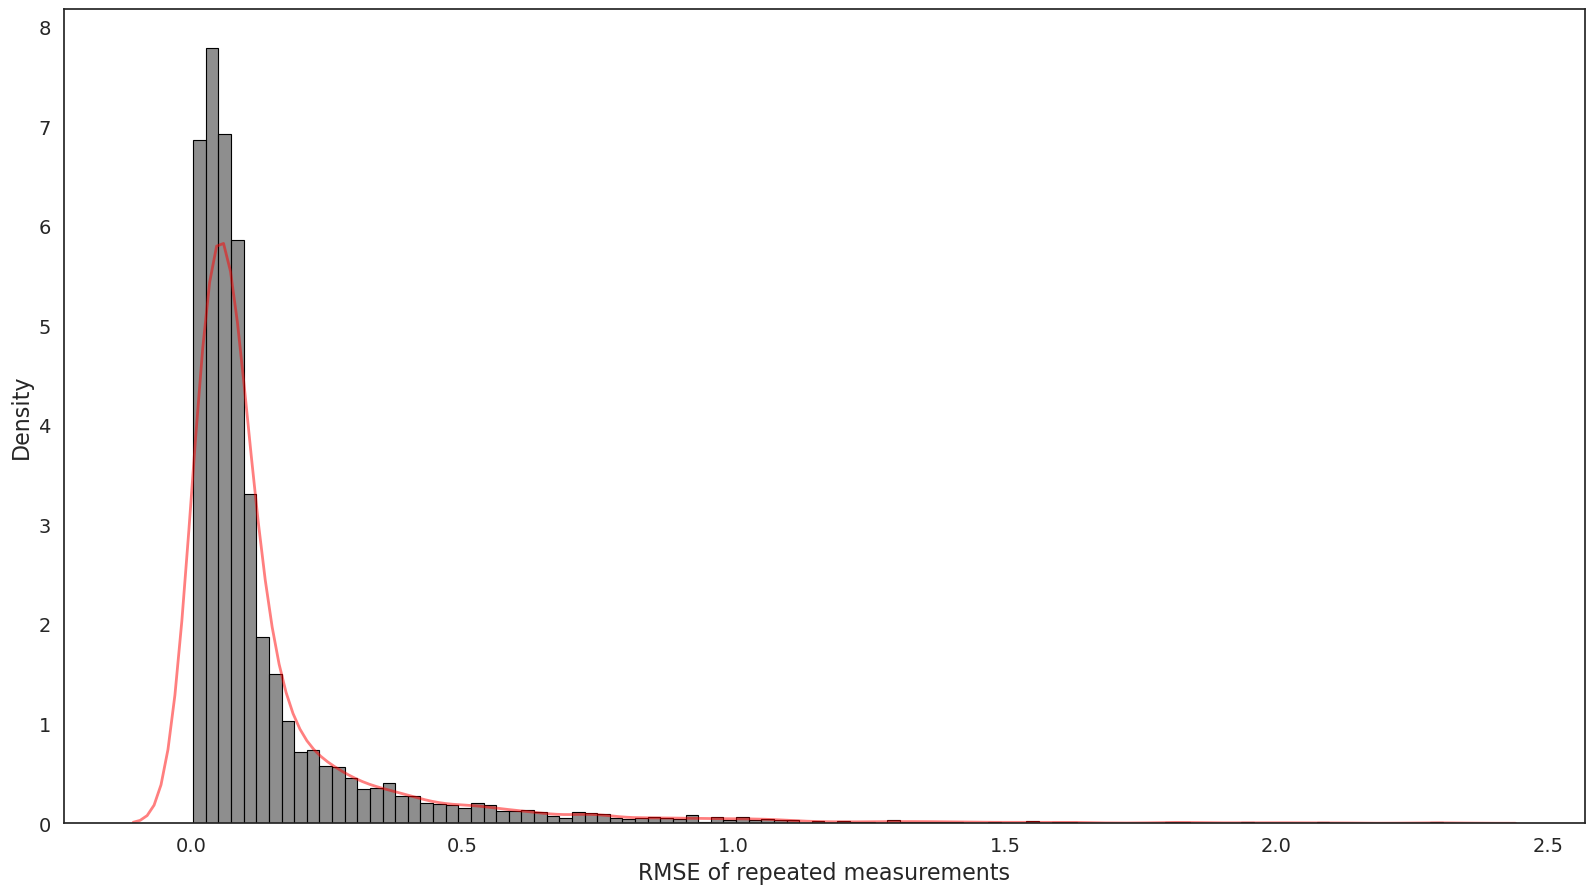

Number of expression dedup entries that had dups: 10441


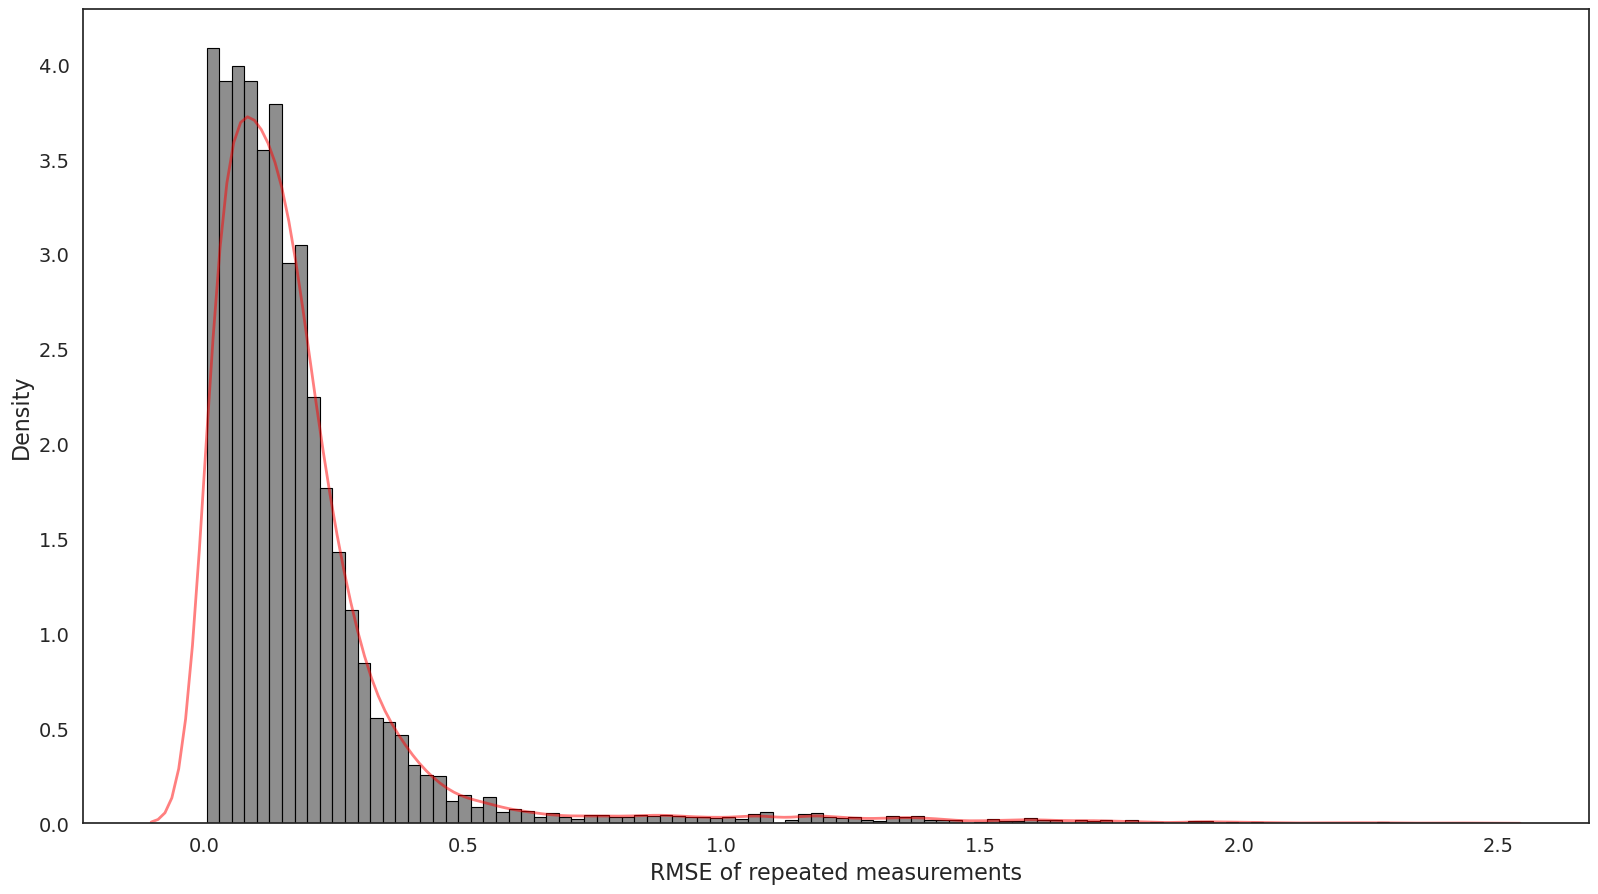

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_value_distribution(df, value_col:str, x_label:str, save_as:str=None):
    """ 
    Plots the given value distribution. 
    """
    sns.set_theme()
    sns.set_context('talk')
    sns.set(style='white')
    plt.figure(figsize=(16, 9))
    plt.rcParams['font.family'] = 'sans-serif'

    # Create histogram and kde plot
    sns.histplot(df[value_col], kde=False, stat='density', bins=100, color='dimgrey', edgecolor='black')
    sns.kdeplot(df[value_col], color='red', linewidth=2, alpha=0.5)

    plt.tight_layout()
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel(x_label, fontsize=16)
    plt.ylabel('Density', fontsize=16)
    plt.show()

data_dir = '../../data/dms'
dups_only_b_combined_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_binding_dups_rmse.csv"), sep=',', header=0)
print('Number of binding dedup entries that had dups:', len(dups_only_b_combined_df))
plot_value_distribution(dups_only_b_combined_df, "rmse_binding", "RMSE of repeated measurements")

dups_only_e_combined_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_expression_dups_rmse.csv"), sep=',', header=0)
print('Number of expression dedup entries that had dups:', len(dups_only_e_combined_df))
plot_value_distribution(dups_only_e_combined_df, "rmse_expression", "RMSE of repeated measurements")

Let's try to make a plot that compares these measured pseudo RMSE values with those from our models. 

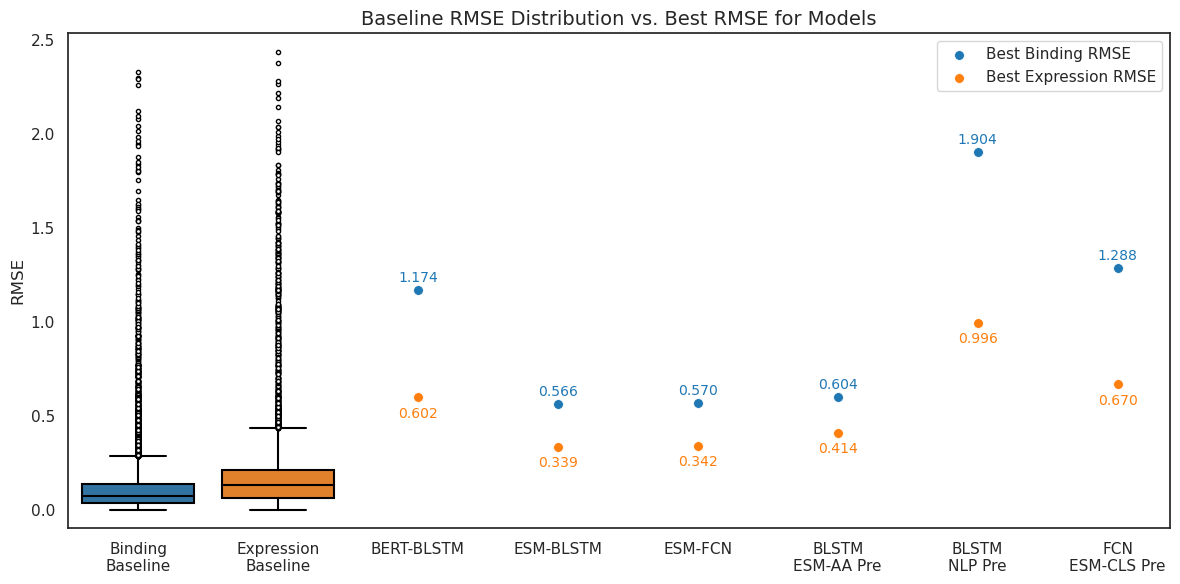

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Load baseline RMSE values for binding and expression
data_dir = '../../data/dms'
baseline_binding_rmse_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_binding_dups_rmse.csv"), sep=',', header=0)
baseline_binding_rmse = baseline_binding_rmse_df['rmse_binding']

baseline_expression_rmse_df = pd.read_csv(os.path.join(data_dir, "mutation_combined_DMS_OLD_expression_dups_rmse.csv"), sep=',', header=0)
baseline_expression_rmse = baseline_expression_rmse_df['rmse_expression']

# Load model RMSE values over epochs
results_dir = '../../results/run_results'

# Function to load and get best RMSE for a model
def get_best_rmse(file_path, rmse_column='Test RMSE'):
    df = pd.read_csv(file_path, sep=',', header=0)
    return df[rmse_column].min()

# Define model paths and RMSE column names
model_paths = {
    'BERT-BLSTM': {
        'binding': "bert_blstm/bert_blstm-DMS_OLD-binding-2024-11-14_03-58/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv",
        'expression': "bert_blstm/bert_blstm-DMS_OLD-expression-2024-11-14_03-59/bert_blstm-DMS_OLD-train_82178_test_20545_metrics.csv",
        'rmse_column': 'Test BLSTM RMSE'
    },
    'ESM-BLSTM': {
        'binding': "esm_blstm/esm_blstm-DMS_OLD-binding-2024-10-22_14-38/esm_blstm-DMS_OLD_binding-train_82178_test_20545_metrics.csv",
        'expression': "esm_blstm/esm_blstm-DMS_OLD-expression-2024-10-22_14-39/esm_blstm-DMS_OLD_expression-train_82178_test_20545_metrics.csv",
        'rmse_column': 'Test RMSE'
    },
    'ESM-FCN': {
        'binding': "esm_fcn/esm_fcn-DMS_OLD-binding-2024-10-09_22-50/esm_fcn-DMS_OLD_binding-train_82178_test_20545_metrics.csv",
        'expression': "esm_fcn/esm_fcn-DMS_OLD-expression-2024-10-09_22-51/esm_fcn-DMS_OLD_expression-train_82178_test_20545_metrics.csv",
        'rmse_column': 'Test RMSE'
    },
    'BLSTM\nESM-AA Pre': {
        'binding': "blstm-ESM_AA_preembedded/blstm-ESM_AA_preembedded-DMS_OLD-binding-2024-11-12_21-02/blstm-ESM_AA_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv",
        'expression': "blstm-ESM_AA_preembedded/blstm-ESM_AA_preembedded-DMS_OLD-expression-2024-11-12_20-57/blstm-ESM_AA_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv",
        'rmse_column': 'Test RMSE'
    },
    'BLSTM\nNLP Pre': {
        'binding': "blstm-NLP_preembedded/blstm-NLP_preembedded-DMS_OLD-binding-2024-11-13_12-00/blstm-NLP_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv",
        'expression': "blstm-NLP_preembedded/blstm-NLP_preembedded-DMS_OLD-expression-2024-11-13_12-00/blstm-NLP_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv",
        'rmse_column': 'Test RMSE'
    },
    'FCN\nESM-CLS Pre': {
        'binding': "fcn-ESM_CLS_preembedded/fcn-ESM_CLS_preembedded-DMS_OLD-binding-2024-11-14_02-07/fcn-ESM_CLS_preembedded-DMS_OLD_binding-train_82178_test_20545_metrics.csv",
        'expression': "fcn-ESM_CLS_preembedded/fcn-ESM_CLS_preembedded-DMS_OLD-expression-2024-11-14_02-06/fcn-ESM_CLS_preembedded-DMS_OLD_expression-train_82178_test_20545_metrics.csv",
        'rmse_column': 'Test RMSE'
    }
}

# Load RMSE values for each model (binding and expression)
model_rmses_binding = {}
model_rmses_expression = {}

for model, paths in model_paths.items():
    binding_file = os.path.join(results_dir, paths['binding'])
    expression_file = os.path.join(results_dir, paths['expression'])
    
    model_rmses_binding[model] = get_best_rmse(binding_file, paths['rmse_column'])
    model_rmses_expression[model] = get_best_rmse(expression_file, paths['rmse_column'])

# Prepare data for plotting
model_names = ['Binding\nBaseline', 'Expression\nBaseline'] + list(model_rmses_binding.keys())
binding_rmse_values = [None, None] + list(model_rmses_binding.values())
expression_rmse_values = [None, None] + list(model_rmses_expression.values())

# Create a DataFrame for the baseline data
baseline_data = pd.DataFrame({
    'Type': ['Binding'] * len(baseline_binding_rmse) + ['Expression'] * len(baseline_expression_rmse),
    'RMSE': list(baseline_binding_rmse) + list(baseline_expression_rmse)
})

# Plot
plt.figure(figsize=(12, 6))

# Baseline boxplots
sns.boxplot(
    x='Type', y='RMSE', data=baseline_data, 
    palette={'Binding': 'tab:blue', 'Expression': 'tab:orange'}, 
    showfliers=True,
    boxprops=dict(edgecolor='black', linewidth=1.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='white', markersize=3)
)

# Binding scatter for models
sns.scatterplot(x=range(2, len(model_names)), y=binding_rmse_values[2:],
                color='tab:blue', s=50, label='Best Binding RMSE')

# Expression scatter for models
sns.scatterplot(x=range(2, len(model_names)), y=expression_rmse_values[2:],
                color='tab:orange', s=50, label='Best Expression RMSE')

# Add labels to the points
for i, (b_value, e_value) in enumerate(zip(binding_rmse_values[2:], expression_rmse_values[2:])):
    plt.text(i + 2, b_value + 0.025, f'{b_value:.3f}', ha='center', va='bottom', color='tab:blue', fontsize=10)
    plt.text(i + 2, e_value - 0.05, f'{e_value:.3f}', ha='center', va='top', color='tab:orange', fontsize=10)

# Customize the plot
plt.title('Baseline RMSE Distribution vs. Best RMSE for Models', fontsize=14)
plt.xlabel('')
plt.xticks(range(len(model_names)), model_names)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
#plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-axis limits to accommodate all data points
y_min = min(baseline_data['RMSE'].min(), min(binding_rmse_values[2:]), min(expression_rmse_values[2:]))
y_max = max(baseline_data['RMSE'].max(), max(binding_rmse_values[2:]), max(expression_rmse_values[2:]))
plt.ylim(y_min - 0.1, y_max + 0.1)

plt.tight_layout()
plt.show()